# Sleep data inventory

This notebook inspects the privacy-safe FIT and JSON-derived tables. It does not save personal outputs to the repository.

In [1]:
from garmin_daylio_analysis.sleep import load_local_sleep_analysis

sleep = load_local_sleep_analysis()
nights, segments, signals = sleep.nights, sleep.segments, sleep.signals

In [2]:
nights[["sleep_date", "fit_coverage", "summary_coverage"]].value_counts(dropna=False), signals.notna().mean().sort_values()

(sleep_date  fit_coverage  summary_coverage
 2024-01-06  False         True                1
 2024-01-07  False         True                1
 2024-01-08  False         True                1
 2024-01-11  False         True                1
 2024-01-12  False         True                1
                                              ..
 2026-08-31  False         True                1
 2026-09-01  False         True                1
 2026-09-02  False         True                1
 2026-09-03  False         True                1
 2026-09-04  False         True                1
 Name: count, Length: 109, dtype: int64,
 steps               0.003415
 intensity           0.177378
 activity_type       0.177378
 heart_rate          0.708638
 stress_level        0.994615
 respiration_rate    0.994790
 timestamp_utc       1.000000
 sleep_date          1.000000
 timestamp_local     1.000000
 dtype: float64)

In [3]:
# This cell can also be run on its own after restarting the kernel.
if not {"nights", "segments", "signals"}.issubset(globals()):
    from garmin_daylio_analysis.sleep import load_local_sleep_analysis

    sleep = load_local_sleep_analysis()
    nights, segments, signals = sleep.nights, sleep.segments, sleep.signals

if segments.empty:
    print("No FIT sleep-stage segments were included in this Garmin export. Sleep summaries are available below.")
else:
    display(segments.groupby("raw_stage").duration_minutes.describe())

No FIT sleep-stage segments were included in this Garmin export. Sleep summaries are available below.


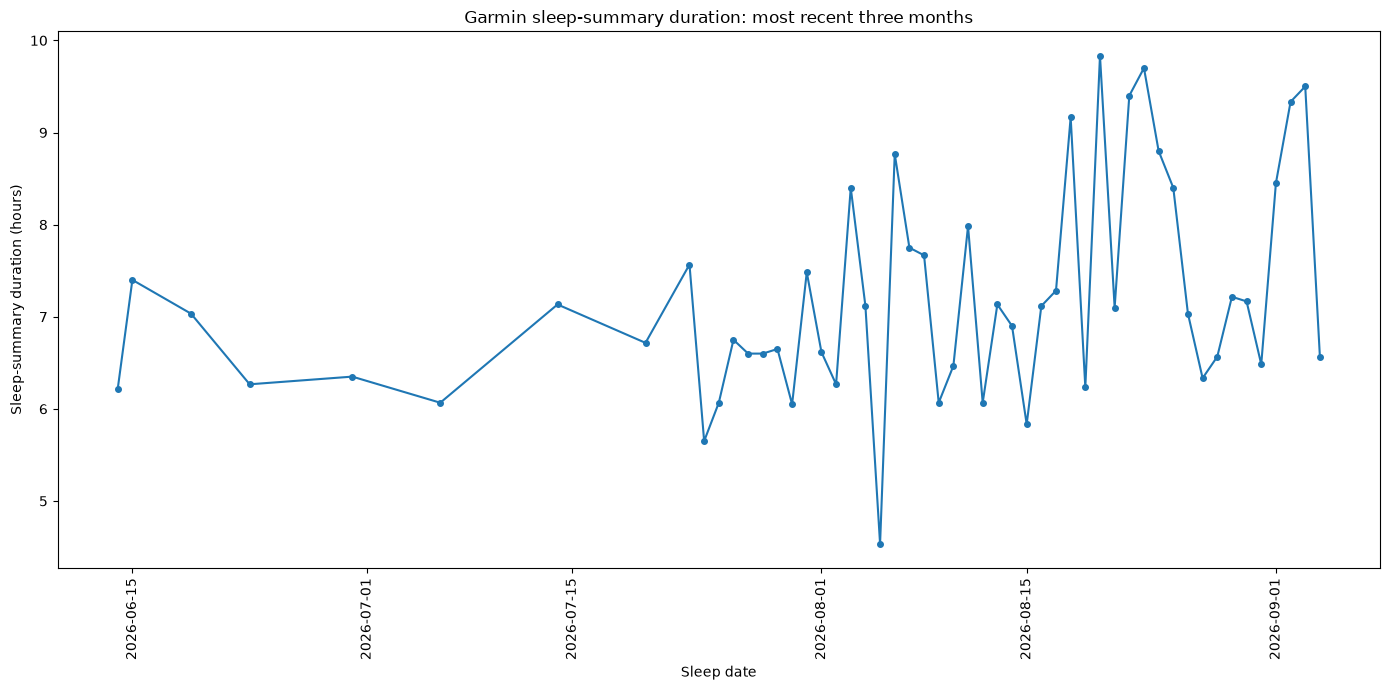

In [4]:
# Show a stage hypnogram when available; otherwise show the sleep-summary duration trend.
if not {"nights", "segments", "signals"}.issubset(globals()):
    from garmin_daylio_analysis.sleep import load_local_sleep_analysis

    sleep = load_local_sleep_analysis()
    nights, segments, signals = sleep.nights, sleep.segments, sleep.signals

import matplotlib.pyplot as plt
import pandas as pd
if segments.empty:
    recent_cutoff = (pd.Timestamp(nights.sleep_date.max()) - pd.DateOffset(months=3)).date()
    recent_nights = nights[nights.sleep_date >= recent_cutoff]
    plt.figure(figsize=(14, 7))
    plt.plot(recent_nights.sleep_date, recent_nights.summary_total_seconds / 3600, marker="o", markersize=4)
    plt.ylabel("Sleep-summary duration (hours)")
    plt.xlabel("Sleep date")
    plt.xticks(rotation=90)
    plt.title("Garmin sleep-summary duration: most recent three months")
    plt.tight_layout()
else:
    chosen_date = nights.sleep_date.max()
    plot = segments[segments.sleep_date == chosen_date].copy()
    stage_order = {"awake": 4, "rem": 3, "light": 2, "deep": 1, "unmeasurable": 0}
    plt.step(plot.start_local, plot.raw_stage.map(stage_order), where="post")
    plt.yticks(list(stage_order.values()), list(stage_order))
    plt.title(f"Garmin hypnogram: {chosen_date}")

## Overnight heart rate

The values below are Garmin heart-rate readings recorded within each detected sleep window. They are descriptive, not clinical measurements.

,sleep_date,summary_total_seconds,heart_rate_mean_bpm,heart_rate_min_bpm,heart_rate_max_bpm,heart_rate_readings
0,2026-06-14,22380.0,49.505119,38.0,96.0,293
1,2026-06-15,26640.0,47.767241,39.0,80.0,348
2,2026-06-19,25320.0,48.670695,39.0,81.0,331
3,2026-06-23,22560.0,52.102473,40.0,79.0,283
4,2026-06-30,22860.0,45.014981,39.0,74.0,267
5,2026-07-06,21840.0,45.965116,41.0,74.0,258
6,2026-07-14,25680.0,45.964286,38.0,106.0,308
7,2026-07-20,24180.0,55.361446,40.0,86.0,332
8,2026-07-23,27240.0,45.969325,39.0,77.0,326
9,2026-07-24,20340.0,42.577778,37.0,66.0,225


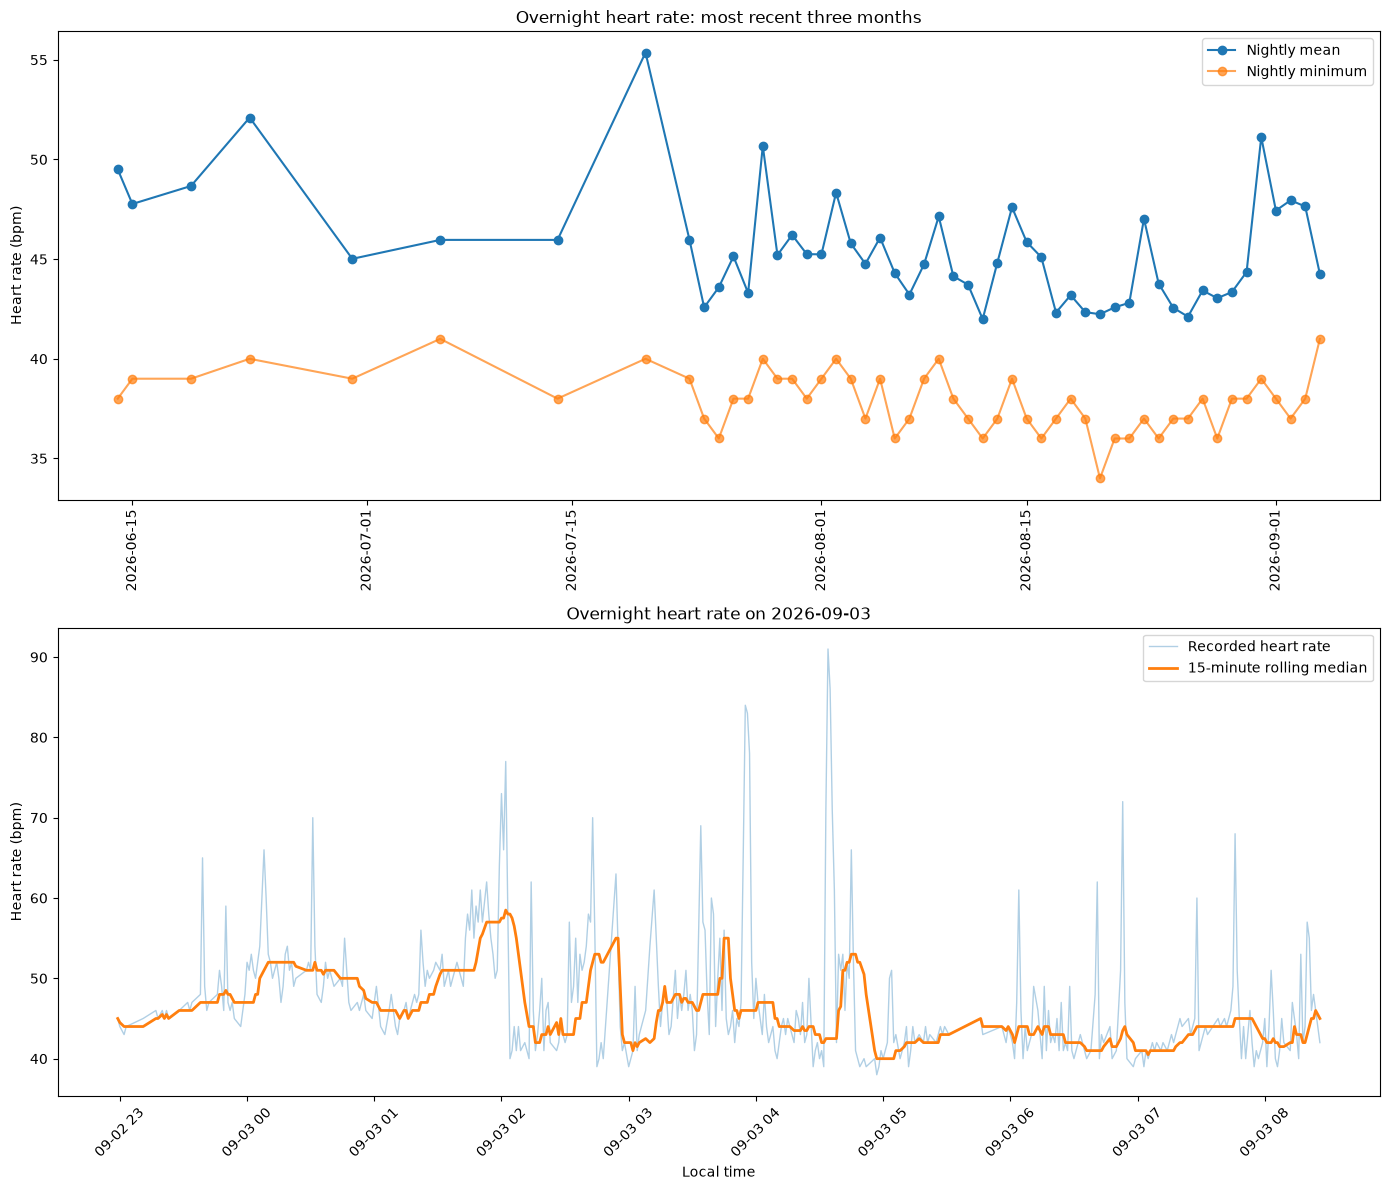

In [5]:
# Heart-rate summaries and a representative overnight trace for the same recent three-month period.
recent_cutoff = (pd.Timestamp(nights.sleep_date.max()) - pd.DateOffset(months=3)).date()
recent_hr = signals.loc[(signals.sleep_date >= recent_cutoff) & signals.heart_rate.notna()].copy()
nightly_hr = (
    recent_hr.groupby("sleep_date", as_index=False).heart_rate
    .agg(heart_rate_mean_bpm="mean", heart_rate_min_bpm="min", heart_rate_max_bpm="max", heart_rate_readings="count")
)
recent_sleep_hr = nights.loc[nights.sleep_date >= recent_cutoff, ["sleep_date", "summary_total_seconds"]].merge(nightly_hr, on="sleep_date", how="left")
display(recent_sleep_hr.sort_values("sleep_date"))

fig, (trend_ax, trace_ax) = plt.subplots(2, 1, figsize=(14, 12))
trend_ax.plot(nightly_hr.sleep_date, nightly_hr.heart_rate_mean_bpm, marker="o", label="Nightly mean")
trend_ax.plot(nightly_hr.sleep_date, nightly_hr.heart_rate_min_bpm, marker="o", alpha=0.7, label="Nightly minimum")
trend_ax.set_ylabel("Heart rate (bpm)")
trend_ax.set_title("Overnight heart rate: most recent three months")
trend_ax.tick_params(axis="x", rotation=90)
trend_ax.legend()

representative_hr_date = nightly_hr.loc[nightly_hr.heart_rate_readings >= 100, "sleep_date"].max()
latest_hr = recent_hr.loc[recent_hr.sleep_date == representative_hr_date].sort_values("timestamp_local").set_index("timestamp_local").heart_rate
trace_ax.plot(latest_hr.index, latest_hr, alpha=0.35, linewidth=1, label="Recorded heart rate")
trace_ax.plot(latest_hr.rolling("15min", min_periods=1).median().index, latest_hr.rolling("15min", min_periods=1).median(), linewidth=2, label="15-minute rolling median")
trace_ax.set_ylabel("Heart rate (bpm)")
trace_ax.set_xlabel("Local time")
trace_ax.set_title(f"Overnight heart rate on {representative_hr_date}")
trace_ax.tick_params(axis="x", rotation=45)
trace_ax.legend()
fig.tight_layout()